# Amostragem de arestas para treino e teste
- Amostrar **nós** ao inves de arestas (nós mais recentes).
- **Arestas positivas**: depois de amostrar nós, filtrar arestas que terminam nos nós amostrados.
- **Arestas negativas**: criar manualmente seguindo algumas regras.
- - todos os pares u e v devem ser criados de forma que u esteja no treino e v esteja no teste.
- - negativos semanticamente similares: u e v com alta similaridade semântica. computar e selecionar o top-k que atenda a porcentagem desejada.
- - negativos aleatórios e temporalmente plausiveis: u e v selecionados aleatóriamente, porém respeitando restrições de tempo.
- - puramente aleatório: selecionar links arbitrarios entre u e v. é para ser trivial. ao menos, impor que u seja anterior a v. selecionar por ultimo e evitar que sejam geradas arestas repetidas dos outros conjuntos.


# Carregando Dados

In [1]:
import pickle
import numpy as np
from glm_based_event_analysis.utils.general import load_config

In [2]:
G = pickle.load(open("/exp_local/kenzosaki/data/iptc/graphs/economy_event_graph.pkl", "rb"))
config = load_config("../src/glm_based_event_analysis/config/evaluation/link_prediction.yaml", print_config=True)


Loaded configuration file (../src/glm_based_event_analysis/config/evaluation/link_prediction.yaml):
	 split: {'test_pct': 0.2, 'true_edge_quantity': 1.0, 'seed': 2026}
	 negative_examples: {'hard_semantic_pct': 0.4, 'temporal_plausible_pct': 0.4, 'random_pct': 0.2, 'max_temporal_window': 31}
	 embedding: {'model_name': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2', 'batch_size': 128}


In [3]:
G.number_of_nodes(), G.number_of_edges()

(9995, 16317)

In [4]:
sorted_nodes = sorted(G.nodes(data=True), key=lambda x: x[1].get("when", 0), reverse=True)

In [5]:
sorted_nodes[:10]

[('25_imf_malawi_economy_2026-06-01',
  {'what': "An IMF deal for Malawi is at risk due to concerns about the country's economic state.",
   'where': 'Malawi',
   'when': Timestamp('2026-06-01 06:38:09+0000', tz='UTC'),
   'who': 'IMF, Malawi government, economic experts',
   'how': 'Experts are urging Malawi to address its economic issues before the IMF deal can proceed.',
   'why': "Concerns over Malawi's economic stability are jeopardizing the IMF deal."}),
 ('7_etf_investments_aum_2026-06-01',
  {'what': 'Mirae Asset Global Investments achieved the 12th position in global ETF management based on Assets Under Management.',
   'where': 'South Korea',
   'when': Timestamp('2026-06-01 06:31:47+0000', tz='UTC'),
   'who': 'Mirae Asset Global Investments',
   'how': 'Through strategic investment and expansion of ETF product offerings.',
   'why': 'Growth in ETF investments and successful asset management strategies.'}),
 ('24_interest_rates_housing_job_creation_2026-06-01',
  {'what': 'R

# Facilitando o desenvolvimento

In [6]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import dot_score

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu126).


In [7]:
#all_whats = [G.nodes[node].get("what", "") for node in G.nodes()]
#
#model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
#embeddings = model.encode(all_whats, batch_size=512, normalize_embeddings=True, show_progress_bar=True)
#
## calcular similaridade semântica (cosine similarity)
#similarities = dot_score(embeddings, embeddings).cpu().numpy()
#
#semantic_similarities = similarities

# Classe para split de treino e teste

In [8]:
from glm_based_event_analysis.link_prediction.evaluation import EventGraphSplitter
from glm_based_event_analysis.utils.graph import remove_edges_from_graph

In [9]:
splitter = EventGraphSplitter(G, config) # TODO: bug -> nó alvo não pode ser origem

In [10]:
# testes
splitter._true_edge_quantity = 1000

In [11]:
#splitter._semantic_similarities = semantic_similarities
test_edges = splitter.get_test_edges(return_similarities=True)

- Total available true edges 2480


- Total available negative pairs: 15980536


- Creating random negatives: 100%|██████████| 200/200 [00:00<00:00, 950012.23it/s]


In [12]:
# checando se ha interseção entre nos de treino e teste
train_nodes = set(splitter._train_nodes)
test_nodes = set(splitter._test_nodes)
intersection = train_nodes.intersection(test_nodes)
print(f"Interseção entre nós de treino e teste: {intersection}")

Interseção entre nós de treino e teste: set()


In [13]:
len(splitter._train_nodes), len(splitter._test_nodes)

(7996, 1999)

In [14]:
test_edges[-1]

{'u': '9737_london_letters_reserve_bank_2021-03-18',
 'v': '1192_youth_unemployment_chaos_london_2026-04-08',
 'label': False,
 'label_description': 'random negative',
 'semantic_similarity': np.float32(0.078522176)}

In [15]:
G_train = remove_edges_from_graph(G, test_edges)

In [16]:
# todos os nos alvo serao removidos do grafo.
# nao permitir que um no alvo seja no de origem de outra aresta (negativa ou positiva) do conjunto de teste.

In [17]:
# TODO: bug -> no alvo nao pode ser origem, pois os alvos serao removidos do grafo
invalid = 0
for edge in test_edges:
    if edge["u"] not in G_train:
        invalid += 1
        print(f"label: {edge['label']} - {edge['label_description']} - anchor node {edge['u']} not in G_train, skipping.")
print(f"Invalid test edges (anchor node not in G_train): {invalid} out of {len(test_edges)}")

# armazenar nos de origem
# na hora de criar nos neg, verificar nao há violação (no alvo nao pode ser origem)
# fazer com sets deve ser facil

Invalid test edges (anchor node not in G_train): 0 out of 2001


# Validando arestas criadas

In [18]:
import pandas as pd
import networkx as nx

In [19]:
def is_edge_valid(G, edge: tuple[str, str]) -> bool:

    if G.has_edge(edge[0], edge[1]):
        return True
    else:
        return False

In [20]:
def sample_and_show_edges(edges_df: pd.DataFrame, G: nx.DiGraph, target: str, sample_size: int = 5):
    # amostrando exemplos de um grupo e visualizando informações da aresta
    print(f"Target group: {target}\n")
    
    # amostrando arestas
    sample_df = edges_df[edges_df["label_description"] == target].sample(n=sample_size)

    # visualizando informações das arestas amostradas
    for _, row in sample_df.iterrows():
        u = row["u"]
        v = row["v"]
        label = row["label"]

        print(f"Edge: ({u} -> {v}) | Label: {label} | Semantic Similarity: {row['semantic_similarity']:.4f}")

        print(f"Event u ({u})")
        for attr, value in G.nodes[u].items():
            print(f"\t {attr}: {value}")
        
        print(f"Event v ({v})")
        for attr, value in G.nodes[v].items():
            print(f"\t {attr}: {value}")

        print(f"Edge attributes")
        if G.has_edge(u, v):
            for attr, value in G.edges[u, v].items():
                print(f"\t {attr}: {value}")
        else:
            print("\t Negative edge, no attributes")

        print("-" * 10)

In [21]:
# no alvo nao pode ser origem, pois os alvos serao removidos do grafo
invalid = 0
for edge in test_edges:
    if edge["u"] not in G_train:
        invalid += 1
        print(f"label: {edge['label']} - {edge['label_description']} - anchor node {edge['u']} not in G_train, skipping.")
print(f"Invalid test edges (anchor node not in G_train): {invalid} out of {len(test_edges)}")

Invalid test edges (anchor node not in G_train): 0 out of 2001


In [22]:
edges_df = pd.DataFrame(test_edges)

In [23]:
edges_df.head()

,u,v,label,label_description,semantic_similarity
0,3191_gold_record_highs_climbing_2025-02-23,3155_boom_bust_back_2025-03-03,True,hard true edge (below 25th percentile similarity),0.272496
1,3870_israel_economy_war_2024-09-26,3833_israel_economy_war_2024-10-04,True,easy true edge (above 75th percentile similarity),0.842782
2,4332_macron_france_polls_2024-06-14,4268_france_debt_crisis_macron_2024-06-28,True,easy true edge (above 75th percentile similarity),0.692238
3,301_uk_borrowing_financial_strain_rachel_reeve...,202_dirty_money_uk_financial_sector_2026-05-24,True,easy true edge (above 75th percentile similarity),0.602042
4,1210_private_credit_financial_risk_paul_krugma...,1038_finance_economy_us_2026-04-16,True,easy true edge (above 75th percentile similarity),0.661108


In [24]:
edges_df.groupby("label").size()

label
False    1001
True     1000
dtype: int64

In [25]:
edges_df.groupby("label_description").size()

label_description
easy true edge (above 75th percentile similarity)                 250
hard semantic negative                                            400
hard true edge (below 25th percentile similarity)                 250
medium true edge (between 25th and 50th percentile similarity)    250
medium true edge (between 50th and 75th percentile similarity)    250
random negative                                                   201
temporal plausible negative                                       400
dtype: int64

In [26]:
is_valid = edges_df.apply(lambda row: is_edge_valid(G, (row["u"], row["v"])), axis=1)
edges_df["is_valid"] = is_valid

In [27]:
# verificando se os labels estao corretos
correct_labels = (edges_df["label"] == edges_df["is_valid"]).sum()
total = len(edges_df)
print(f"Correctly labeled edges: {correct_labels}/{total}")

Correctly labeled edges: 2001/2001


# Amostrando exemplos de cada grupo

In [28]:
edges_df["label_description"].unique()

<ArrowStringArray>
[             'hard true edge (below 25th percentile similarity)',
              'easy true edge (above 75th percentile similarity)',
 'medium true edge (between 25th and 50th percentile similarity)',
 'medium true edge (between 50th and 75th percentile similarity)',
                                         'hard semantic negative',
                                    'temporal plausible negative',
                                                'random negative']
Length: 7, dtype: str

In [29]:
sample_and_show_edges(edges_df, G, "easy true edge (above 75th percentile similarity)")

Target group: easy true edge (above 75th percentile similarity)

Edge: (735_india_hormuz_crisis_oil_prices_2026-04-29 -> 682_hormuz_crisis_oil_prices_opec_2026-05-03) | Label: True | Semantic Similarity: 0.6886
Event u (735_india_hormuz_crisis_oil_prices_2026-04-29)
	 what: India is significantly impacted by the Hormuz Crisis due to the Iran war, leading to soaring oil prices.
	 where: India
	 when: 2026-04-29 07:00:00+00:00
	 who: India, Iran, oil markets, potentially other nations involved in the Iran war.
	 how: The conflict in Iran is causing instability in the Hormuz Strait, a critical shipping route for oil, leading to supply disruptions and price increases.
	 why: The Iran war is disrupting oil supplies through the Strait of Hormuz, causing a surge in oil prices and impacting India's economy.
Event v (682_hormuz_crisis_oil_prices_opec_2026-05-03)
	 what: A crisis is unfolding in the Hormuz region, causing oil prices to surge and raising tensions within OPEC.
	 where: United Arab

In [30]:
sample_and_show_edges(edges_df, G, "hard true edge (below 25th percentile similarity)")

Target group: hard true edge (below 25th percentile similarity)

Edge: (709_fertiliser_urea_imports_2026-05-01 -> 202_dirty_money_uk_financial_sector_2026-05-24) | Label: True | Semantic Similarity: 0.3302
Event u (709_fertiliser_urea_imports_2026-05-01)
	 what: Government secures 37 lakh ton urea imports for the kharif season despite the West Asia crisis.
	 where: India
	 when: 2026-05-01 07:00:00+00:00
	 who: Indian government, fertiliser companies, potentially West Asian nations.
	 how: Through securing imports of 37 lakh tons of urea.
	 why: To ensure sufficient fertiliser supply for the kharif season despite disruptions caused by the West Asia crisis.
Event v (202_dirty_money_uk_financial_sector_2026-05-24)
	 what: At least £325bn of illicit funds are flowing through the UK annually.
	 where: United Kingdom
	 when: 2026-05-24 07:00:00+00:00
	 who: Financial sector, individuals involved in illicit financial activities.
	 how: Through the UK's financial system, potentially involving

In [31]:
sample_and_show_edges(edges_df, G, "hard semantic negative")

Target group: hard semantic negative

Edge: (5519_egypt_economic_crisis_csis_2023-10-03 -> 1383_egypt_economy_crisis_2026-03-17) | Label: False | Semantic Similarity: 0.8660
Event u (5519_egypt_economic_crisis_csis_2023-10-03)
	 what: Discussion of Egypt's ongoing economic crisis.
	 where: Egypt
	 when: 2023-10-03 07:00:00+00:00
	 who: Khalid Ikram, CSIS
	 how: Through a discussion or presentation hosted by the Center for Strategic and International Studies.
	 why: To analyze and discuss the causes and potential consequences of Egypt's economic crisis.
Event v (1383_egypt_economy_crisis_2026-03-17)
	 what: A potential crisis in Egypt raises concerns about the global economy.
	 where: Egypt
	 when: 2026-03-17 07:00:00+00:00
	 who: Egypt, global economy
	 how: The article suggests a potential crisis unfolding in Egypt, with implications for the global economic landscape.
	 why: A crisis in Egypt could act as a warning sign for broader economic instability.
Edge attributes
	 Negative edge

In [32]:
sample_and_show_edges(edges_df, G, "temporal plausible negative")

Target group: temporal plausible negative

Edge: (1251_fuel_crisis_staff_cuts_victorian_businesses_2026-04-05 -> 4179_low_growth_economy_challenge_2024-07-16) | Label: False | Semantic Similarity: 0.2703
Event u (1251_fuel_crisis_staff_cuts_victorian_businesses_2026-04-05)
	 what: Victorian businesses are being forced to cut staff due to unsustainable fuel costs.
	 where: Australia
	 when: 2026-04-05 07:00:00+00:00
	 who: Victorian businesses and their staff
	 how: Businesses are reducing their workforce to mitigate the financial impact of rising fuel prices.
	 why: Unsustainable fuel costs are making it difficult for businesses to operate profitably.
Event v (4179_low_growth_economy_challenge_2024-07-16)
	 what: The UK economy faces a significant challenge of low growth.
	 where: United Kingdom
	 when: 2024-07-16 07:00:00+00:00
	 who: The House of Commons Library, UK economy
	 how: Through analysis and reporting by the House of Commons Library.
	 why: To highlight the current economic

In [33]:
sample_and_show_edges(edges_df, G, "random negative")

Target group: random negative

Edge: (4697_economic_security_europe_economic_policy_2024-03-28 -> 2180_indonesia_finance_growth_2025-10-01) | Label: False | Semantic Similarity: 0.2627
Event u (4697_economic_security_europe_economic_policy_2024-03-28)
	 what: Discussion on how Europe should approach economic security.
	 where: Germany
	 when: 2024-03-28 07:31:47+00:00
	 who: European policymakers and economists.
	 how: Through review and discussion of economic policies.
	 why: To address and define strategies for economic security in Europe.
Event v (2180_indonesia_finance_growth_2025-10-01)
	 what: Indonesia's finance chief prioritizes faster economic growth before considering easing financial restrictions.
	 where: Indonesia
	 when: 2025-10-01 07:00:00+00:00
	 who: Indonesia's finance chief
	 how: By maintaining current financial limits until economic growth accelerates.
	 why: To ensure sustainable economic development and stability.
Edge attributes
	 Negative edge, no attributes
--

# Visualizando distribuição das similaridades

In [34]:
import seaborn as sns 

<Axes: ylabel='Count'>

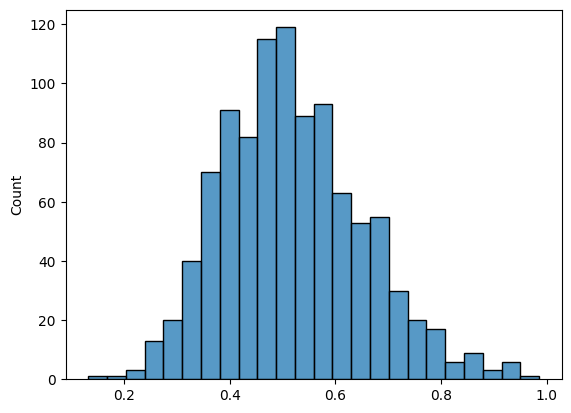

In [35]:
sns.histplot(splitter._true_labels_similarities)

In [36]:
# computando quartis
easy_threshold = np.percentile(splitter._true_labels_similarities, 75)
medium_threshold = np.percentile(splitter._true_labels_similarities, 50)
hard_threshold = np.percentile(splitter._true_labels_similarities, 25)
print(f"Easy threshold (75th percentile): {easy_threshold}")
print(f"Medium threshold (50th percentile): {medium_threshold}")
print(f"Hard threshold (25th percentile): {hard_threshold}")

Easy threshold (75th percentile): 0.601812481880188
Medium threshold (50th percentile): 0.5060374140739441
Hard threshold (25th percentile): 0.42166465520858765


# Serializando arestas de teste

Provisório, remover e criar um script a parte depois.

In [37]:
import json

In [38]:
for edge in test_edges:
    del edge["semantic_similarity"] # removendo pois só e usado para teste

In [39]:
# with open("/exp_local/kenzosaki/data/iptc/politcs_labels.json", "w") as f:
#     json.dump(test_edges, f, indent=2)